## Questão 1

Para as funções listadas abaixo, realizar a otimização em $\mathbb{R}^2$ e $\mathbb{R}^3$ com o algoritmo do gradiente realizando 20 inicializações diferentes (com sorteio aleatório da solução candidata inicial e variação da taxa de ajuste $\alpha$). Trace gráficos da evolução do valor da função a cada iteração.

In [17]:
import numpy as np
import matplotlib.pyplot as plt

def esfera(x, n=None):
    """
    f(x) = Σ(xi²) para i=1 até n
    
    Args:
        x: array de valores
        n: número de termos (se None, usa todo o array x)
    
    Returns:
        Soma dos quadrados dos n primeiros elementos de x
    """
    x = np.array(x) if not isinstance(x, np.ndarray) else x
    
    if n is None:
        n = len(x)
    else:
        n = min(n, len(x))
    
    return np.sum(x[:n]**2)

def ackley(x, n=None):
    """
    f(x) = -20*exp(-0.2*√(1/n * Σxi²)) - exp(1/n * Σcos(2πxi)) + 20 + e
    
    Args:
        x: array de valores
        n: número de termos (se None, usa todo o array x)
    
    Returns:
        Valor da função de Ackley
    """
    x = np.array(x) if not isinstance(x, np.ndarray) else x
    
    if n is None:
        n = len(x)
    else:
        n = min(n, len(x))
    
    # Primeiro termo: -20 * exp(-0.2 * sqrt(1/n * Σxi²))
    sum_squares = np.sum(x[:n]**2)
    term1 = -20 * np.exp(-0.2 * np.sqrt((1/n) * sum_squares))
    
    # Segundo termo: -exp(1/n * Σcos(2πxi))
    sum_cos = np.sum(np.cos(2 * np.pi * x[:n]))
    term2 = -np.exp((1/n) * sum_cos)
    
    # Resultado final: term1 + term2 + 20 + e
    return term1 + term2 + 20 + np.e

In [18]:
def grad_esfera(x, n=None):
    """
    Gradiente da função esfera
    
    Para f1(x) = Σ(xi²), temos:
    ∂f1/∂xi = 2*xi
    
    Args:
        x: array ou lista de valores
        n: número de termos (se None, usa todo o array x)
    
    Returns:
        Array com o gradiente (derivadas parciais)
    """
    x = np.array(x) if not isinstance(x, np.ndarray) else x
    
    if n is None:
        n = len(x)
    else:
        n = min(n, len(x))
    
    # Gradiente: cada componente é 2*xi
    gradient = 2 * x[:n]
    
    return gradient


def gradiente_descendente_esfera(valores_iniciais, num_iteracoes, alfa):
    valores_iteracoes = []
    valores_atuais = valores_iniciais
    for i in range(0, num_iteracoes):
        grad_atual = grad_esfera(x=valores_atuais)
        valores_atuais = valores_atuais - alfa * np.transpose(grad_atual)
        valores_iteracoes.append(valores_atuais)

    return valores_iteracoes


In [19]:
def grad_ackley(x):
    """
    Gradiente da Função de Ackley (todas as derivadas parciais)
    
    Parâmetros:
    x : array-like
        Vetor de coordenadas. Deve ter 2 ou 3 elementos.
        
    Retorna:
    numpy.ndarray
        Vetor gradiente [∂f/∂x1, ∂f/∂x2, ...] 
        
    Erro:
    ValueError
        Se o vetor x não tiver exatamente 2 ou 3 elementos
    """
    x = np.array(x, dtype=float)
    n = len(x)
    
    if n == 2:
        # Caso R²
        x1, x2 = x[0], x[1]
        gradient = np.zeros(2)
        
        # Norma para os primeiros termos
        norm = np.sqrt(x1**2 + x2**2)
        
        # Fatores comuns
        if norm == 0:
            first_term_factor = 0
        else:
            first_term_factor = 2.828 * np.exp(-0.2 * np.sqrt(0.5 * (x1**2 + x2**2))) / norm
        
        cos_sum = np.cos(2*np.pi*x1) + np.cos(2*np.pi*x2)
        second_term_factor = np.pi * np.exp(0.5 * cos_sum)
        
        # ∂f/∂x1
        gradient[0] = first_term_factor * x1 + second_term_factor * np.sin(2*np.pi*x1)
        
        # ∂f/∂x2  
        gradient[1] = first_term_factor * x2 + second_term_factor * np.sin(2*np.pi*x2)
        
        return gradient
        
    elif n == 3:
        # Caso R³
        x1, x2, x3 = x[0], x[1], x[2]
        gradient = np.zeros(3)
        
        # Norma para os primeiros termos
        norm = np.sqrt(x1**2 + x2**2 + x3**2)
        
        # Fatores comuns
        if norm == 0:
            first_term_factor = 0
        else:
            first_term_factor = (5.6562 / np.sqrt(3)) * np.exp(-0.2 * np.sqrt((x1**2 + x2**2 + x3**2) / 3)) / norm
        
        cos_sum = np.cos(2*np.pi*x1) + np.cos(2*np.pi*x2) + np.cos(2*np.pi*x3)
        second_term_factor = (2*np.pi/3) * np.exp(cos_sum/3)
        
        # ∂f/∂x1
        gradient[0] = first_term_factor * x1 + second_term_factor * np.sin(2*np.pi*x1)
        
        # ∂f/∂x2
        gradient[1] = first_term_factor * x2 + second_term_factor * np.sin(2*np.pi*x2)
        
        # ∂f/∂x3
        gradient[2] = first_term_factor * x3 + second_term_factor * np.sin(2*np.pi*x3)
        
        return gradient
        
    else:
        raise ValueError(f"A função aceita apenas vetores de 2 ou 3 dimensões. Recebido: {n} dimensões.")
    
def gradiente_descendente_ackley(valores_iniciais, num_iteracoes, alfa):
    valores_iteracoes = []
    valores_atuais = valores_iniciais
    for i in range(0, num_iteracoes):
        grad_atual = grad_ackley(x=valores_atuais)
        valores_atuais = valores_atuais - alfa * np.transpose(grad_atual)
        valores_iteracoes.append(valores_atuais)

    return valores_iteracoes


In [20]:
initial_value = np.random.randint(-5,5,size=2)
alpha = 0.2
N = 500
pontos_grad_desc_esfera = gradiente_descendente_esfera(initial_value,N,alpha)
pontos_grad_desc_ackley = gradiente_descendente_ackley(initial_value,N,alpha)


In [21]:
initial_value

array([-3,  2], dtype=int32)

In [22]:
print(f"Valores finais encontrados para a esfera : {pontos_grad_desc_esfera[-1]}")
print(f"Valores finais encontrados para a função de Ackley : {pontos_grad_desc_ackley[-1]}")

Valores finais encontrados para a esfera : [-3.57064313e-111  2.38042875e-111]
Valores finais encontrados para a função de Ackley : [-0.3797448   0.49105331]


In [23]:
pontos_grad_desc_esfera = np.transpose(pontos_grad_desc_esfera)
pontos_grad_desc_ackley = np.transpose(pontos_grad_desc_ackley)

In [24]:
x_range = np.linspace(-3, 3, 20)
y_range = np.linspace(-3, 3, 20)
X, Y = np.meshgrid(x_range, y_range)
    
Z = np.zeros_like(X)

for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        point = [X[i, j], Y[i, j]]
        Z[i, j] = esfera(point)


In [25]:
X2, Y2 = np.meshgrid(x_range, y_range)
    
Z2 = np.zeros_like(X2)

for i in range(X2.shape[0]):
    for j in range(X2.shape[1]):
        point = [X2[i, j], Y2[i, j]]
        Z2[i, j] = ackley(point)


Text(0.5, 0, 'f(x1, x2)')

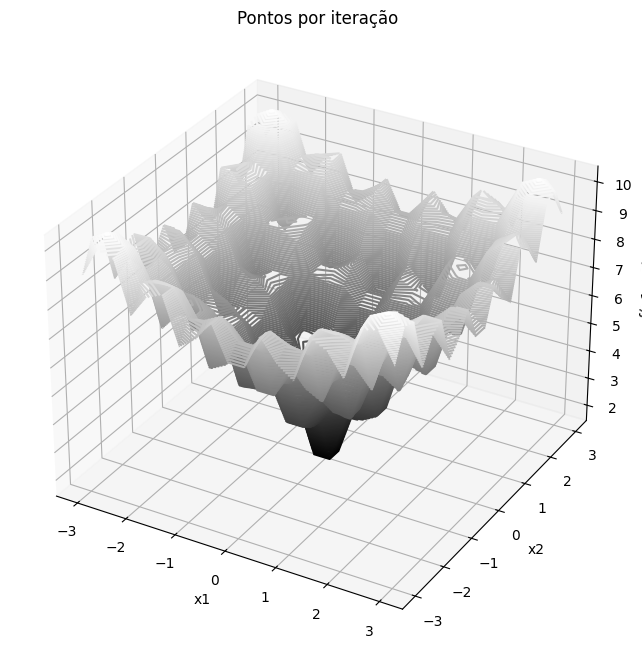

In [26]:
fig = plt.figure(figsize=(12, 8))  # Aumentar o tamanho do plot
ax = fig.add_subplot(111, projection="3d")
# Alterar a ordem de plotagem para que os pontos fiquem na frente da superfície
ax.contour3D(
    X2, Y2, Z2, 150, cmap="gray", alpha=1
)  # Tornar a superfície semitransparente
ax.set_title("Pontos por iteração")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_zlabel("f(x1, x2)")


# Questão 3

In [27]:
def particle_swarm(y, num_particles, cognitive_constant, social_constant, inertia_weight, num_iterations):
    """
    Implementação do algoritmo de otimização por enxame de partículas (PSO).
    
    Args:
        y: Função a ser minimizada.
        num_particles: Número de partículas no enxame.
        cognitive_constant: Constante cognitiva (pessoal).
        social_constant: Constante social (global).
        inertia_weight: Peso da inércia.
        num_iterations: Número de iterações do PSO.
    
    Retorna:
        Melhor posição encontrada e seu valor.
    """
    # Inicialização das partículas
    particles = np.random.uniform(-5, 5, (num_particles, 2))
    velocities = np.random.uniform(-1, 1, (num_particles, 2))
    personal_best_positions = particles.copy()
    personal_best_values = np.array([y(p) for p in particles])
    global_best_position = personal_best_positions[np.argmin(personal_best_values)].copy()
    global_best_value = np.min(personal_best_values)
    best_positions = []
    best_values = []
    for i in range(num_iterations):
        for n in range(num_particles):
            # Atualização da velocidade
            r1, r2 = np.random.uniform(0, 1, 2)
            velocities[n] = (
                inertia_weight * velocities[n]
                + cognitive_constant * r1 * (personal_best_positions[n] - particles[n])
                + social_constant * r2 * (global_best_position - particles[n])
            )
            # Atualização da posição
            particles[n] += velocities[n]
            # Atualização do valor da função
            current_value = y(particles[n])
            # Atualização do melhor pessoal
            if current_value < personal_best_values[n]:
                personal_best_values[n] = current_value
                personal_best_positions[n] = particles[n].copy()
            # Atualização do melhor global
            if current_value < global_best_value:
                global_best_value = current_value
                global_best_position = particles[n].copy()
        best_positions.append(global_best_position.copy())
        best_values.append(global_best_value)
    return global_best_position, global_best_value, best_positions, best_values


### a) População de 20 indivíduos.

In [28]:
pontos_pso_esfera = particle_swarm(esfera, num_particles=20, cognitive_constant=1.5, social_constant=1.5, inertia_weight=0.5, num_iterations=1000)
pontos_pso_ackley = particle_swarm(ackley, num_particles=20, cognitive_constant=1.5, social_constant=1.5, inertia_weight=0.5, num_iterations=1000)
print(f"Melhor posição encontrada para a esfera: {pontos_pso_esfera[0]}")
print(f"Melhor valor encontrado para a esfera: {pontos_pso_esfera[1]}")
print(f"Melhor posição encontrada para a função de Ackley: {pontos_pso_ackley[0]}")
print(f"Melhor valor encontrado para a função de Ackley: {pontos_pso_ackley[1]}")

Melhor posição encontrada para a esfera: [7.47556873e-112 1.42130440e-111]
Melhor valor encontrado para a esfera: 2.5789474821080465e-222
Melhor posição encontrada para a função de Ackley: [3.37197764e-16 1.35701384e-16]
Melhor valor encontrado para a função de Ackley: 4.440892098500626e-16
